In [10]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import save_image
import matplotlib.pyplot as plt
import os

In [11]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Hyperparameters
latent_size = 64
hidden_size = 256
image_size = 784
num_epochs = 30
batch_size = 100
learning_rate = 0.0002

# Create directory for generated images
sample_dir = 'samples'
os.makedirs(sample_dir, exist_ok=True)

In [12]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

mnist = torchvision.datasets.MNIST(root='./data',
                                   train=True,
                                   transform=transform,
                                   download=True)

data_loader = torch.utils.data.DataLoader(dataset=mnist,
                                          batch_size=batch_size,
                                          shuffle=True)

In [13]:
D = nn.Sequential(
    nn.Linear(image_size, hidden_size),
    nn.LeakyReLU(0.2),
    nn.Linear(hidden_size, hidden_size),
    nn.LeakyReLU(0.2),
    nn.Linear(hidden_size, 1),
    nn.Sigmoid()
).to(device)

In [14]:
G = nn.Sequential(
    nn.Linear(latent_size, hidden_size),
    nn.ReLU(),
    nn.Linear(hidden_size, hidden_size),
    nn.ReLU(),
    nn.Linear(hidden_size, image_size),
    nn.Tanh()
).to(device)

In [15]:
criterion = nn.BCELoss()

d_optimizer = torch.optim.Adam(D.parameters(), lr=learning_rate)
g_optimizer = torch.optim.Adam(G.parameters(), lr=learning_rate)

In [16]:
total_step = len(data_loader)

for epoch in range(num_epochs):
    for i, (images, _) in enumerate(data_loader):

        images = images.reshape(batch_size, -1).to(device)

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # Train Discriminator
        outputs = D(images)
        d_loss_real = criterion(outputs, real_labels)

        z = torch.randn(batch_size, latent_size).to(device)
        fake_images = G(z)
        outputs = D(fake_images.detach())
        d_loss_fake = criterion(outputs, fake_labels)

        d_loss = d_loss_real + d_loss_fake

        d_optimizer.zero_grad()
        g_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # Train Generator
        z = torch.randn(batch_size, latent_size).to(device)
        fake_images = G(z)
        outputs = D(fake_images)
        g_loss = criterion(outputs, real_labels)

        d_optimizer.zero_grad()
        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

        if (i+1) % 200 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{total_step}], "
                  f"d_loss: {d_loss.item():.4f}, g_loss: {g_loss.item():.4f}")

    # Save generated images
    fake_images = fake_images.reshape(fake_images.size(0), 1, 28, 28)
    save_image(fake_images, os.path.join(sample_dir, f'fake_images-{epoch+1}.png'))

Epoch [1/30], Step [200/600], d_loss: 0.0315, g_loss: 4.6497
Epoch [1/30], Step [400/600], d_loss: 0.2469, g_loss: 4.6398
Epoch [1/30], Step [600/600], d_loss: 0.0299, g_loss: 5.6350
Epoch [2/30], Step [200/600], d_loss: 0.3114, g_loss: 4.6266
Epoch [2/30], Step [400/600], d_loss: 0.1136, g_loss: 4.5197
Epoch [2/30], Step [600/600], d_loss: 0.7550, g_loss: 4.5219
Epoch [3/30], Step [200/600], d_loss: 0.3578, g_loss: 3.6721
Epoch [3/30], Step [400/600], d_loss: 0.2544, g_loss: 5.3729
Epoch [3/30], Step [600/600], d_loss: 0.9493, g_loss: 2.4941
Epoch [4/30], Step [200/600], d_loss: 0.4390, g_loss: 1.9264
Epoch [4/30], Step [400/600], d_loss: 0.2685, g_loss: 3.4954
Epoch [4/30], Step [600/600], d_loss: 0.4966, g_loss: 3.5625
Epoch [5/30], Step [200/600], d_loss: 0.5177, g_loss: 2.3481
Epoch [5/30], Step [400/600], d_loss: 0.2570, g_loss: 2.6925
Epoch [5/30], Step [600/600], d_loss: 0.2412, g_loss: 3.4401
Epoch [6/30], Step [200/600], d_loss: 0.9713, g_loss: 3.3076
Epoch [6/30], Step [400/

In [17]:
z = torch.randn(batch_size, latent_size).to(device)
fake_images = G(z)

fake_images = fake_images.reshape(fake_images.size(0), 1, 28, 28)
save_image(fake_images, 'final_generated_images.png')

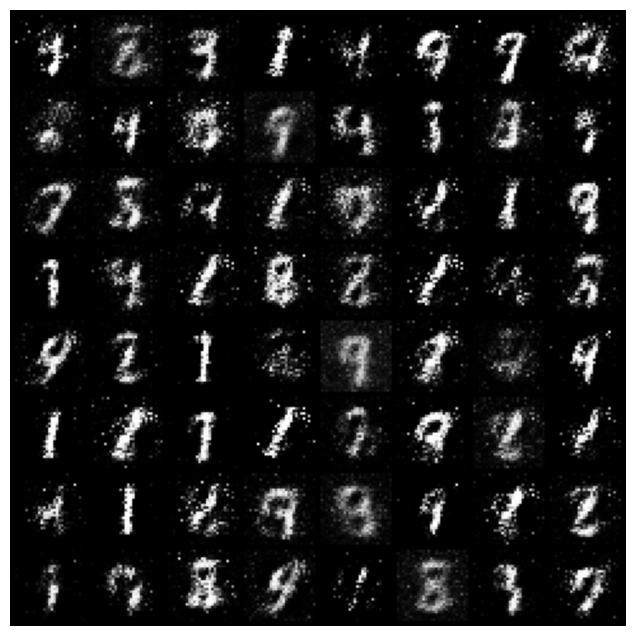

In [18]:
import matplotlib.pyplot as plt
import numpy as np

grid = torchvision.utils.make_grid(fake_images[:64], nrow=8, normalize=True)
npimg = grid.cpu().numpy()

plt.figure(figsize=(8,8))
plt.imshow(np.transpose(npimg, (1,2,0)))
plt.axis('off')
plt.show()